# Dangi baseline — experiment notebook
Use this notebook as the central control panel for **Stage A: LV centre regression and slice alignment**.
The network and algorithms stay in `dangi/`; this notebook configures runs and displays results.

**Workflow:** configuration → inspect data/model → train → inspect curves → evaluate → align/export.
Choose the project `.venv` kernel. For interactive GPU work, start Jupyter in a GPU allocation
using account **`jjparkcv98`**. Training can also be submitted to Slurm from this notebook.

A first **Run All** previews one labelled case and prepares commands. Training, evaluation,
and alignment run only when their switches below are enabled. Missing checkpoints are handled
without falling back to smoke-test or random weights. See [README](README.md) for assumptions.


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / 'dangi' / 'model.py').exists():
    ROOT = Path('/home/sincheol/CMRI/Dangi')  # Change if this repository was moved.
if not (ROOT / 'dangi' / 'model.py').exists():
    raise FileNotFoundError('Set ROOT to the Dangi repository directory.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import json
import shlex
import numpy as np
import torch
import nibabel as nib
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from dangi.config import Config
from dangi.data import make_split, case_paths, read_case, preprocess
from dangi.model import DangiCenterNet
from dangi.align import load_model, align_stack, align_nifti
from dangi.workbench import (training_command, submit_training, run_command,
                             job_status, read_history, plot_history, plot_alignment)

print(f'Repository: {ROOT}\nKernel: {sys.executable}')
print(f'PyTorch: {torch.__version__} | CUDA available: {torch.cuda.is_available()}')


Repository: /home/sincheol/CMRI/Dangi
Kernel: /home/sincheol/CMRI/Dangi/.venv/bin/python
PyTorch: 2.9.0+cu128 | CUDA available: False


## 1. Run configuration
Edit this cell to select the experiment. Keep a separate `RUN_DIR` for each configuration.
Training automatically resumes `last.pt` in that directory; the trainer checks that settings match.
`FRAME_INDEX` is a **zero-based array index** used only for a 4D inference input.


In [2]:
DATA_DIR = ROOT / 'ACDC/database'
RUN_DIR = ROOT / 'runs/dangi'
CHECKPOINT = RUN_DIR / 'best.pt'
PYTHON = Path(sys.executable)  # Must also be accessible on the Slurm compute node.

EPOCHS = 100
BATCH_SIZE = 32
WORKERS = 4
SEED = 2018
MIN_BP_PIXELS = 1
TRAIN_MODE = 'slurm'         # 'slurm' submits a job; 'local' uses this kernel's GPU node.
PARTITION = 'spgpu'
WALLTIME = '01:30:00'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

EVAL_SUBSET = 'test'         # 'test', 'val', or 'acdc-test'
EVALUATION_PATH = RUN_DIR / f'evaluation_{EVAL_SUBSET}.json'
INPUT_PATH = DATA_DIR / 'testing/patient101/patient101_frame01.nii.gz'
FRAME_INDEX = 0
EXPORT_PATH = RUN_DIR / 'aligned' / INPUT_PATH.name

RUN_TRAINING = False
CHECK_JOB_STATUS = False
RUN_EVALUATION = False
RUN_ALIGNMENT = True
EXPORT_ALIGNMENT = True

# Ground-truth intensity volume (not the _gt segmentation mask).
# This default matches the uncorrupted example input. For corrupted data, select its clean target.
REFERENCE_PATH = DATA_DIR / 'testing/patient101/patient101_frame01.nii.gz'
REFERENCE_FRAME_INDEX = 0  # Zero-based, only used for a 4D reference.
SHOW_GROUND_TRUTH = True  # Displays after RUN_ALIGNMENT=True.


## 2. Data and model overview
Preview a labelled training slice and its target centre. This uses the same preprocessing as training.
Model settings and assumptions are documented in the [README](README.md#method-and-explicit-assumptions).


Patients: {'train': 80, 'val': 10, 'test': 10}


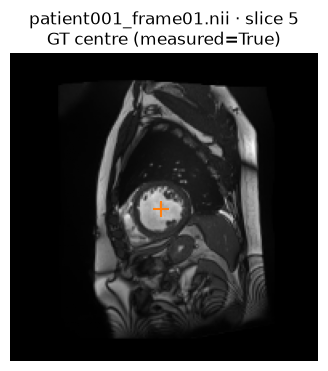

Parameters: 13,286,010
Concatenated features: 51,840
Input: (N, 1, 192, 192) → output: (N, 2), x/y in pixels


In [3]:
config = Config(seed=SEED, min_bp_pixels=MIN_BP_PIXELS)
split = make_split(DATA_DIR, seed=SEED)
print('Patients:', {key: len(value) for key, value in split.items()})
preview_path = next(case_paths(DATA_DIR, split['train']))
preview, targets, measured, _ = read_case(preview_path, config)
z = len(preview) // 2
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(preview[z], cmap='gray', vmin=0, vmax=1)
ax.scatter(*targets[z], c='tab:orange', marker='+', s=130)
ax.set_title(f'{preview_path.stem} · slice {z}\nGT centre (measured={bool(measured[z])})')
ax.axis('off')
plt.show()

# Meta tensors expose architecture/parameter counts without allocating model weights.
with torch.device('meta'):
    architecture = DangiCenterNet()
print(f'Parameters: {sum(p.numel() for p in architecture.parameters()):,}')
print(f'Concatenated features: {architecture.feature_count:,}')
print('Input: (N, 1, 192, 192) → output: (N, 2), x/y in pixels')
del architecture


## 3. Start or resume training
Enable `RUN_TRAINING` above, then run this cell once. Slurm jobs continue after the notebook closes.
The local mode streams training output and occupies this cell until training completes.
Use the same settings on resume. The 90-minute allocation can be increased via `WALLTIME`.


In [4]:
command = training_command(PYTHON, DATA_DIR, RUN_DIR, epochs=EPOCHS,
                           batch_size=BATCH_SIZE, workers=WORKERS, seed=SEED,
                           min_bp_pixels=MIN_BP_PIXELS)
print(shlex.join(command))
if RUN_TRAINING:
    if TRAIN_MODE == 'slurm':
        job_id = submit_training(command, ROOT, RUN_DIR, partition=PARTITION,
                                 walltime=WALLTIME, cpus=max(1, WORKERS))
        print(f'Submitted job {job_id}; logs: {RUN_DIR}/train-{job_id}.log')
    elif TRAIN_MODE == 'local':
        if not torch.cuda.is_available():
            raise RuntimeError('Local training needs a GPU kernel; use Slurm mode otherwise.')
        run_command(command, ROOT)
    else:
        raise ValueError("TRAIN_MODE must be 'slurm' or 'local'")
else:
    print('Command preview only. Set RUN_TRAINING=True to launch.')


/home/sincheol/CMRI/Dangi/.venv/bin/python -u -m dangi.train --data /home/sincheol/CMRI/Dangi/ACDC/database --output /home/sincheol/CMRI/Dangi/runs/dangi --epochs 100 --batch-size 32 --workers 4 --seed 2018 --min-bp-pixels 1 --device cuda --resume /home/sincheol/CMRI/Dangi/runs/dangi/last.pt
Command preview only. Set RUN_TRAINING=True to launch.


In [5]:
if CHECK_JOB_STATUS:
    print(job_status(RUN_DIR))
logs = sorted(RUN_DIR.glob('train-*.log'), key=lambda p: p.stat().st_mtime)
if logs:
    print(f'Latest log: {logs[-1]}')
    print('\n'.join(logs[-1].read_text().splitlines()[-12:]))
else:
    print('No notebook training log yet.')


No notebook training log yet.


## 4. Learning curves and checkpoint
Rerun this cell to refresh the curves while the job trains. The reported epoch and validation
SSD come from the selected checkpoint. Smoke-test checkpoints are identified explicitly.


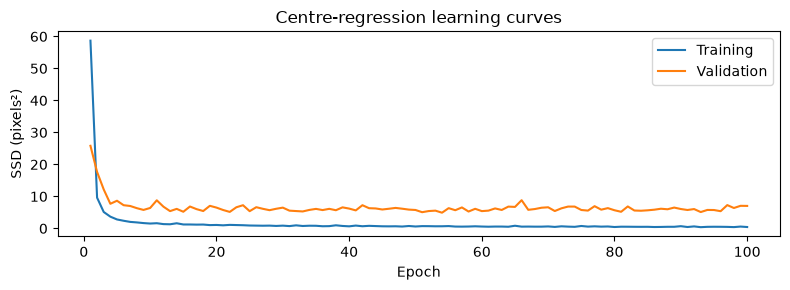

Completed epoch: 100 | last epoch: 168.1s
Checkpoint: /home/sincheol/CMRI/Dangi/runs/dangi/best.pt
Epoch: 54 | best validation SSD: 4.9121


In [6]:
history = read_history(RUN_DIR)
if history:
    plot_history(history)
    plt.show()
    print(f"Completed epoch: {history[-1]['epoch']} | last epoch: {history[-1]['seconds']:.1f}s")
else:
    print('No completed epochs yet.')

if CHECKPOINT.exists():
    payload = torch.load(CHECKPOINT, map_location='cpu', weights_only=True)
    print(f"Checkpoint: {CHECKPOINT}\nEpoch: {payload['epoch']} | best validation SSD: {payload['best_val_ssd']:.4f}")
    if payload.get('max_train_batches') is not None:
        display(Markdown('**Smoke-test weights — not a trained comparison baseline.**'))
    del payload
else:
    print(f'Checkpoint not created yet: {CHECKPOINT}')


## 5. Held-out evaluation
Enable `RUN_EVALUATION` to call the evaluation module. It uses the checkpoint's saved patient split.
The result file includes summary metrics and raw per-slice errors for your comparison tables.


Saved report: /home/sincheol/CMRI/Dangi/runs/dangi/evaluation_test.json (rerun evaluation after changing weights)


| Error (pixels) | Mean | Std | Median | Slices |
|---|---:|---:|---:|---:|
| Initial | 1.586 | 1.171 | 1.359 | 184 |
| Residual | 1.765 | 1.767 | 1.221 | 184 |


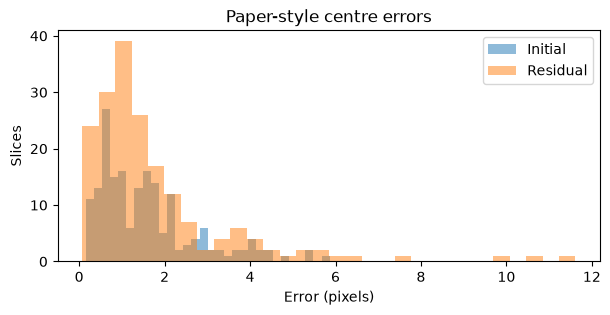

In [7]:
if RUN_EVALUATION:
    if not CHECKPOINT.exists():
        raise FileNotFoundError(f'Train the model first: {CHECKPOINT}')
    run_command([str(PYTHON), '-m', 'dangi.evaluate', '--checkpoint', str(CHECKPOINT),
                 '--data', str(DATA_DIR), '--subset', EVAL_SUBSET,
                 '--output', str(EVALUATION_PATH), '--device', DEVICE], ROOT)
if EVALUATION_PATH.exists():
    report = json.loads(EVALUATION_PATH.read_text())
    print(f'Saved report: {EVALUATION_PATH} (rerun evaluation after changing weights)')
    table = '| Error (pixels) | Mean | Std | Median | Slices |\n|---|---:|---:|---:|---:|\n'
    for key, label in [('before_px', 'Initial'), ('after_px', 'Residual')]:
        row = report[key]
        table += f"| {label} | {row['mean']:.3f} | {row['std']:.3f} | {row['median']:.3f} | {row['count']} |\n"
    display(Markdown(table))
    fig, ax = plt.subplots(figsize=(7, 3))
    for key, label in [('initial_px', 'Initial'), ('residual_px', 'Residual')]:
        errors = [value for case in report['records'] for value in case[key]]
        ax.hist(errors, bins=30, alpha=.5, label=label)
    ax.set(xlabel='Error (pixels)', ylabel='Slices', title='Paper-style centre errors')
    ax.legend()
    plt.show()
else:
    print('No saved evaluation. Enable RUN_EVALUATION after training.')


## 6. Align and inspect an input volume
Enable `RUN_ALIGNMENT` and choose `INPUT_PATH` above. The slider shows each slice before and after
translation. For 4D input, the preview uses `FRAME_INDEX`; export processes all frames.
Centres and applied shifts are available as arrays for your own comparison code.


In [ ]:
alignment = None
if RUN_ALIGNMENT:
    if not CHECKPOINT.exists():
        raise FileNotFoundError(f'Train the model first: {CHECKPOINT}')
    model, trained_config = load_model(CHECKPOINT, DEVICE)
    volume = nib.load(INPUT_PATH)
    if len(volume.shape) == 4:
        if not 0 <= FRAME_INDEX < volume.shape[3]:
            raise ValueError('FRAME_INDEX is outside the cine time dimension')
        frame = nib.Nifti1Image(np.asarray(volume.dataobj[..., FRAME_INDEX]), volume.affine)
    else:
        frame = volume
    before, output_affine = preprocess(frame, trained_config)
    after, centers_xy, applied_shifts_xy = align_stack(model, before, trained_config)
    alignment = dict(before=before, after=after, centers=centers_xy,
                     shifts=applied_shifts_xy, affine=output_affine)
    print(f'{len(before)} slices | shifts in x/y pixels; multiply by {trained_config.spacing_mm} for mm')
    print('First five applied shifts:\n', applied_shifts_xy[:5])

    def show_slice(z):
        plot_alignment(before, after, centers_xy, trained_config.center, z)
        plt.show()

    from ipywidgets import interact, IntSlider
    interact(show_slice, z=IntSlider(value=len(before)//2, min=0, max=len(before)-1,
                                    description='Slice', continuous_update=False))
else:
    print('Enable RUN_ALIGNMENT after selecting a trained checkpoint and input.')


10 slices | shifts in x/y pixels; multiply by 1.5625 for mm
First five applied shifts:
 [[ 2.91660309  1.21893311]
 [ 3.61075592  2.58653259]
 [ 1.94621277  2.64651489]
 [ 3.24648285 -0.0774765 ]
 [ 2.02261353 -0.05033112]]


interactive(children=(IntSlider(value=5, continuous_update=False, description='Slice', max=9), Output()), _dom…

## 6b. Ground truth vs output
Set `REFERENCE_PATH` in the configuration cell to your **clean target intensity volume**,
then enable `RUN_ALIGNMENT`. This viewer shows **ground truth | input | Dangi output | absolute error**
for matched SAX and two orthogonal stack views. Sliders choose the slice and cross-sections.

The default reference is the same uncorrupted ACDC ED frame used by the example input.
For your simulated experiments, change it to the corresponding clean target at the intended cardiac state.
`_gt.nii.gz` files are segmentation labels, not ground-truth intensity volumes.

The reference is sampled onto the output grid using its NIfTI affine, without fitted registration,
independent intensity normalization, or centre alignment. Regions outside reference coverage appear blank.
Dangi straightens the LV centres; its output may differ from the clean reference even without corruption.
When input labels exist, the input panel also shows the measured/propagated and predicted centres.

XZ/YZ panels stretch the stack direction for visibility; all columns use the same display geometry.


In [9]:
import importlib
import dangi.workbench as workbench

# Refresh helper definitions in kernels opened before this section was added.
importlib.reload(workbench)
from dangi.workbench import reference_on_output_grid, plot_ground_truth_comparison

comparison_reference = None
if SHOW_GROUND_TRUTH and alignment is not None:
    reference_volume = nib.load(REFERENCE_PATH)
    if len(reference_volume.shape) == 4:
        if not 0 <= REFERENCE_FRAME_INDEX < reference_volume.shape[3]:
            raise ValueError('REFERENCE_FRAME_INDEX is outside the reference cine')
        reference_volume = nib.Nifti1Image(
            np.asarray(reference_volume.dataobj[..., REFERENCE_FRAME_INDEX]), reference_volume.affine)
    comparison_reference = reference_on_output_grid(
        reference_volume, before.shape, output_affine)
    input_true_centers = input_measured = None
    label_path = INPUT_PATH.with_name(INPUT_PATH.name.replace('.nii.gz', '_gt.nii.gz'))
    if len(volume.shape) == 3 and INPUT_PATH.name.endswith('.nii.gz') and label_path.exists():
        _, input_true_centers, input_measured, _ = read_case(INPUT_PATH, trained_config)
        center_errors = np.linalg.norm(centers_xy-input_true_centers, axis=1)
        print(f'Mean centre error: {center_errors.mean():.3f} pixels (including propagated targets)')
    print(f'Ground truth: {REFERENCE_PATH}')
    print('Error maps use the original intensity units; outside-reference voxels are excluded.')

    def show_ground_truth(z, y, x):
        plot_ground_truth_comparison(comparison_reference, before, after, output_affine,
                                    z, y, x, predicted=centers_xy,
                                    true_centers=input_true_centers, measured=input_measured)
        plt.show()

    from ipywidgets import interact, IntSlider
    interact(show_ground_truth,
             z=IntSlider(value=len(before)//2, min=0, max=len(before)-1,
                         description='SAX slice', continuous_update=False),
             y=IntSlider(value=before.shape[1]//2, min=0, max=before.shape[1]-1,
                         description='XZ view', continuous_update=False),
             x=IntSlider(value=before.shape[2]//2, min=0, max=before.shape[2]-1,
                         description='YZ view', continuous_update=False))
else:
    print('Run alignment first (RUN_ALIGNMENT=True) to show ground truth vs output.')


Mean centre error: 0.875 pixels (including propagated targets)
Ground truth: /home/sincheol/CMRI/Dangi/ACDC/database/testing/patient101/patient101_frame01.nii.gz
Error maps use the original intensity units; outside-reference voxels are excluded.


interactive(children=(IntSlider(value=5, continuous_update=False, description='SAX slice', max=9), IntSlider(v…

## 7. Export for comparison
Enable `EXPORT_ALIGNMENT` to save the corrected NIfTI and transform JSON. The export uses the
1.5625 mm, 192×192 grid; original intensity units, slice spacing and orientation are retained.
For your own pipeline, import `load_model`, `align_stack` or `align_nifti` from `dangi.align`.


In [10]:
if EXPORT_ALIGNMENT:
    if alignment is None:
        raise RuntimeError('Run the alignment cell first with RUN_ALIGNMENT=True.')
    if EXPORT_PATH.resolve() == INPUT_PATH.resolve():
        raise ValueError('Choose an export path different from the input.')
    corrected_volume, transforms = align_nifti(model, volume, trained_config)
    EXPORT_PATH.parent.mkdir(parents=True, exist_ok=True)
    nib.save(corrected_volume, EXPORT_PATH)
    metadata_path = EXPORT_PATH.with_name(EXPORT_PATH.name + '.json')
    metadata_path.write_text(json.dumps(transforms, indent=2) + '\n')
    print(f'Saved {EXPORT_PATH}\nSaved {metadata_path}')
else:
    print('Export disabled. Preview arrays remain available after alignment.')


Saved /home/sincheol/CMRI/Dangi/runs/dangi/aligned/patient101_frame01.nii.gz
Saved /home/sincheol/CMRI/Dangi/runs/dangi/aligned/patient101_frame01.nii.gz.json


## Where the implementation lives
| Task | Python module |
|---|---|
| Constants and assumptions | `dangi/config.py` |
| CNN architecture | `dangi/model.py` |
| ACDC loading and preprocessing | `dangi/data.py` |
| 189 affine augmentations | `dangi/augment.py` |
| Training and resume | `dangi/train.py` |
| Prediction and NIfTI alignment | `dangi/align.py` |
| Paper-style evaluation | `dangi/evaluate.py` |
| Notebook orchestration and plotting | `dangi/workbench.py` |

The notebook does not change the Dangi architecture or introduce a separate training implementation.
